# FMCA interface

### first import modules

In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import sys
import FMCA

!pip install matplotlib
!pip install numpy
import matplotlib.pyplot as plt 
import numpy as np 


ModuleNotFoundError: No module named 'FMCA'

### Replicate simple mocs 

2.0 same as  2.0


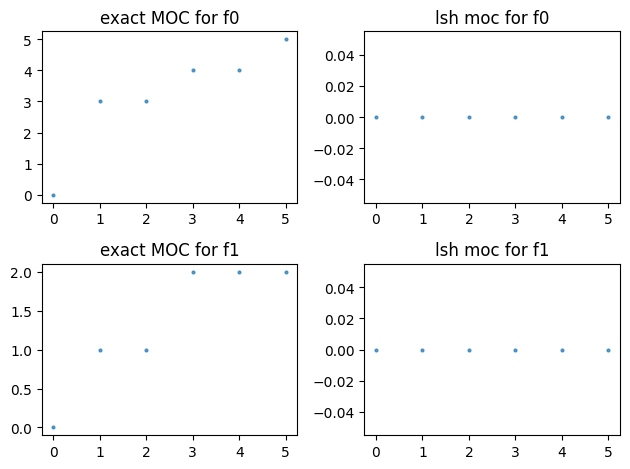

end


In [ ]:
def plot_mocs(fmocs, lshmocs, deltas, savename):
    """
    mocs contains moc values (from 0 to >= max_dist) for k different functions, it is an array of size k x T
    """


    num_functions = len(fmocs)
    fig, ax = plt.subplots(num_functions, 2)

    for j in range(num_functions):
        ax[j,0].plot(deltas, fmocs[j], linestyle='None', marker='o', markersize=2, alpha=0.7)
        ax[j,0].set_title(f"exact MOC for f{j}")
        if lshmocs ==[]:

            ax[j, 1].plot(deltas, deltas*0, linestyle='None', marker='o', markersize=2, alpha=0.7)
            ax[j, 1].set_title(f"lsh moc for f{j}")
        #ax[j, 2].plot(t, aannfmocs[j], linestyle='None', marker='o', markersize=2, alpha=0.7)
        #ax[j, 2].set_title(f"aANN MOC for f{j}")

    fig.tight_layout()
    #plt.savefig(f"{savename}", dpi=300)  # high-resolution PNG
    plt.show()
    plt.clf() 
    plt.close('all')




f1 = np.array([1,3,2,5,4,6], dtype=np.float64).reshape(1, -1)
f2 = np.array([3,2,3,3,4,3], dtype=np.float64).reshape(1, -1)#must have shape (d,n), so use this on 1D array
x =  np.array([1,2,3,4,5,6], dtype=np.float64).reshape(1, -1)


delta_step = 1
edmoc = FMCA.ExactDiscreteModulusOfContinuity()
edmoc.init(x,f1, 0, "EUCLIDEAN", "EUCLIDEAN", "NO")
print(edmoc.computeMocPlot(x, f1, delta_step))
m1 = edmoc.getOmegaT()

edmoc.init(x,f2, 0)
edmoc.computeMocPlot(x, f2, delta_step)
m2 = edmoc.getOmegaT()


print(m2[-1], "same as ", edmoc.computeMoc(x, f2, 7))

#reconstruct values of t_values, having the size of mocplot
t_values = np.zeros(len(m1),dtype=np.float64)

for i in range(1, len(t_values)):
    t_values[i]=t_values[i-1]+delta_step


plot_mocs([m1,m2], [], t_values, "ref_moc.png")

print("end")